<a href="https://colab.research.google.com/github/Rajeshpatra12/Rajeshpatra12/blob/main/Music_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Install dependencies
# !pip install pandas numpy scikit-learn

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Step 2: Load dataset
# (Download "Spotify Tracks DB" dataset from Kaggle & update path)
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/SpotifyFeatures.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (232725, 18)
   genre        artist_name                        track_name  \
0  Movie     Henri Salvador       C'est beau de faire un Show   
1  Movie  Martin & les fées  Perdu d'avance (par Gad Elmaleh)   
2  Movie    Joseph Williams    Don't Let Me Be Lonely Tonight   
3  Movie     Henri Salvador    Dis-moi Monsieur Gordon Cooper   
4  Movie       Fabien Nataf                         Ouverture   

                 track_id  popularity  acousticness  danceability  \
0  0BRjO6ga9RKCKjfDqeFgWV           0         0.611         0.389   
1  0BjC1NfoEOOusryehmNudP           1         0.246         0.590   
2  0CoSDzoNIKCRs124s9uTVy           3         0.952         0.663   
3  0Gc6TVm52BwZD07Ki6tIvf           0         0.703         0.240   
4  0IuslXpMROHdEPvSl1fTQK           4         0.950         0.331   

   duration_ms  energy  instrumentalness key  liveness  loudness   mode  \
0        99373   0.910             0.000  C#    0.3460    -1.828  Major   
1       137373  

In [3]:
# Step 3: Select useful features
df = df[['track_name','artist_name','popularity','danceability','energy','loudness','tempo','genre']]


In [4]:
# Drop duplicates / nulls
df.dropna(inplace=True)
df.drop_duplicates(subset='track_name', inplace=True)

In [5]:
# Step 4: Feature Engineering (combine text features)
df['combined'] = df['artist_name'] + " " + df['genre']

In [6]:
# Step 5: Convert text features into numerical vectors (TF-IDF)
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['combined'])

In [7]:
# Step 6: Compute similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [15]:
# Step 7: Recommendation Function
def recommend_song(song_name, n=5):
    if song_name not in df['track_name'].values:
        return f"❌ Song '{song_name}' not found in dataset."

    idx = df.index[df['track_name'] == song_name][0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    recommended = []
    for i in sim_scores[1:n+1]:
        song_idx = i[0]
        recommended.append(df.iloc[song_idx][['track_name','artist_name','genre']].to_dict())

    return recommended

In [16]:
# Step 8: Test Recommendation System
song = "Shape of You"   # Example (if present in dataset)
print(f"🔎 Recommendations for: {song}\n")
recommendations = recommend_song(song, n=5)

for rec in recommendations:
    print(f"🎵 {rec['track_name']} by {rec['artist_name']} ({rec['genre']})")

🔎 Recommendations for: Shape of You

🎵 It Would Be You by Gary Allan (Country)
🎵 Do You Wish It Was Me? by Gary Allan (Country)
🎵 Pieces by Gary Allan (Country)
🎵 A Showman's Life by Gary Allan (Country)
🎵 Learning How To Bend by Gary Allan (Country)



Visualize the data to show distribution of genres, popularity, and audio features.

## Analyze data

### Subtask:
Explore the dataset to identify interesting aspects for visualization, such as genre distribution, popularity distribution, or the relationship between audio features.


**Reasoning**:
Explore the dataset by printing column names, getting dataframe info, descriptive statistics, and genre value counts to identify interesting aspects for visualization.



In [17]:
print("Column Names:")
print(df.columns)

print("\nDataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())

print("\nGenre Distribution:")
display(df['genre'].value_counts())

Column Names:
Index(['track_name', 'artist_name', 'popularity', 'danceability', 'energy',
       'loudness', 'tempo', 'genre', 'combined'],
      dtype='object')

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 148614 entries, 0 to 232724
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   track_name    148614 non-null  object 
 1   artist_name   148614 non-null  object 
 2   popularity    148614 non-null  int64  
 3   danceability  148614 non-null  float64
 4   energy        148614 non-null  float64
 5   loudness      148614 non-null  float64
 6   tempo         148614 non-null  float64
 7   genre         148614 non-null  object 
 8   combined      148614 non-null  object 
dtypes: float64(4), int64(1), object(4)
memory usage: 11.3+ MB

Descriptive Statistics:


,popularity,danceability,energy,loudness,tempo
count,148614.000000,148614.000000,148614.000000,148614.000000,148614.000000
mean,35.685978,0.535603,0.552324,-10.381606,116.927275
std,17.413949,0.192927,0.280934,6.618407,31.378816
min,0.000000,0.056900,0.000020,-52.457000,30.379000
25%,24.000000,0.406000,0.330000,-13.302000,91.837000
50%,36.000000,0.553000,0.589000,-8.323000,114.886500
75%,48.000000,0.680000,0.791000,-5.659000,138.276000
max,100.000000,0.987000,0.999000,3.744000,242.903000



Genre Distribution:


,count
genre,
Comedy,8640
Classical,8395
Alternative,8305
Anime,8258
Opera,8096
Electronic,7915
Soundtrack,7422
Reggaeton,7367
Blues,7216


## Choose visualization types

### Subtask:
Select appropriate chart types based on the data and the insights you want to convey (e.g., bar charts for counts, histograms for distributions, scatter plots for relationships).


## Generate visualization code

### Subtask:
Write code using a library like Matplotlib or Seaborn to create the chosen visualizations.


**Reasoning**:
Write code to generate the chosen visualizations using matplotlib and seaborn.



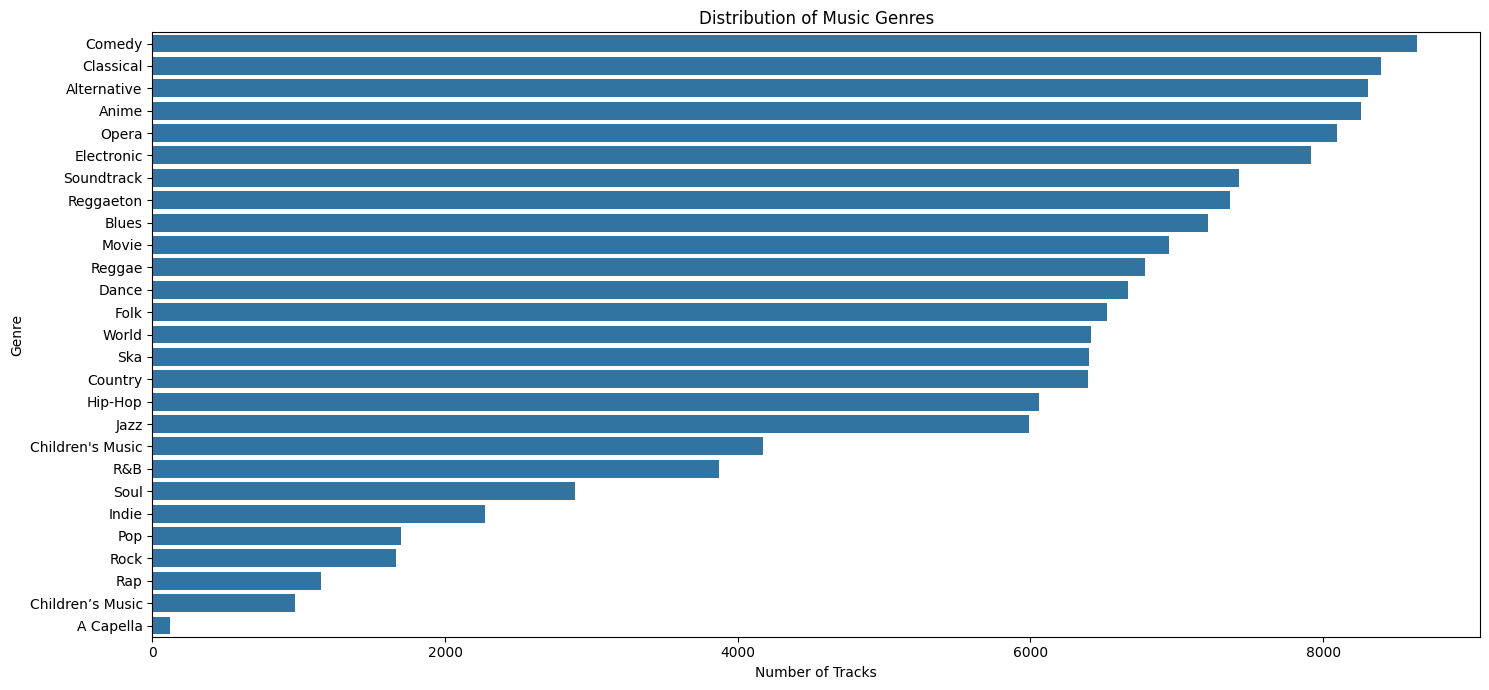

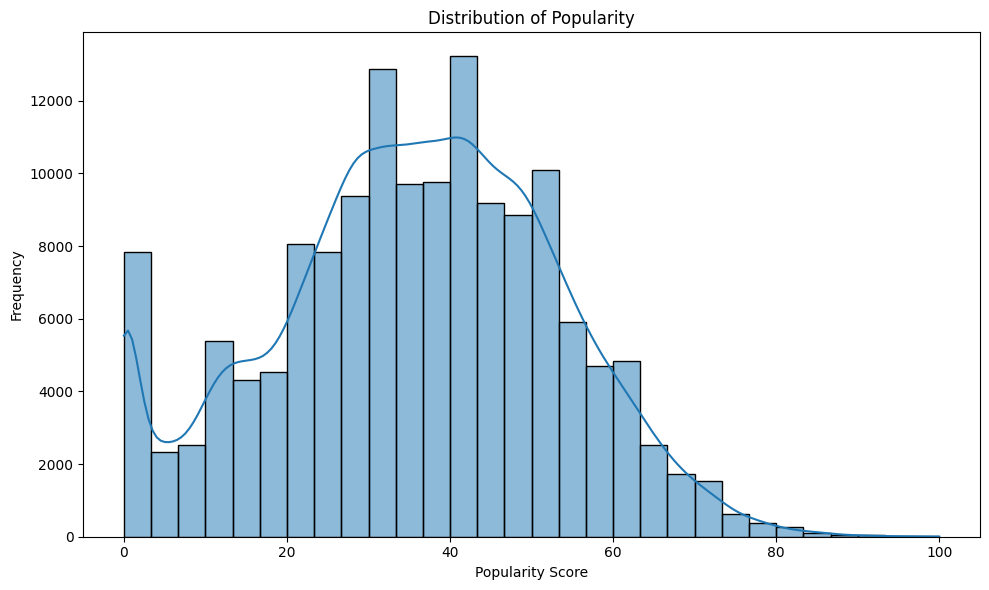

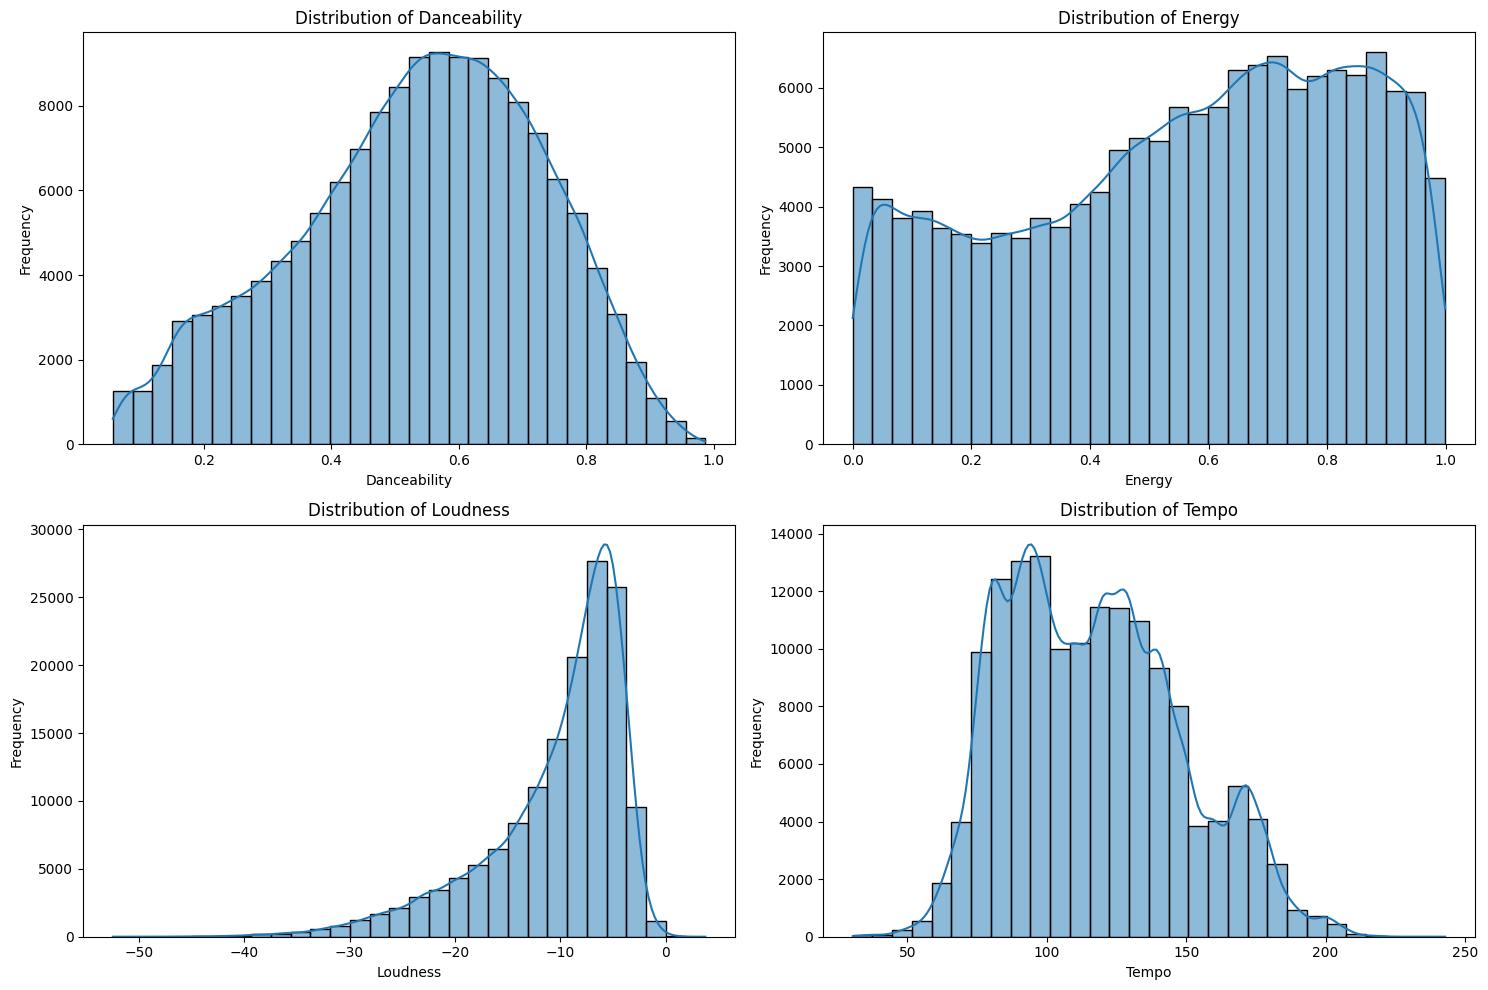

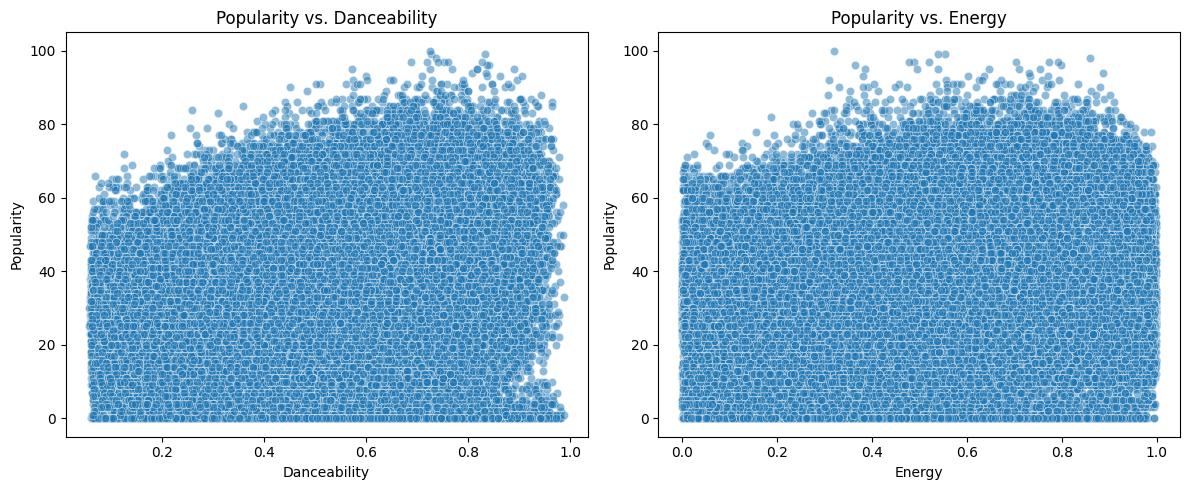

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Bar plot of genre distribution
plt.figure(figsize=(15, 7))
sns.countplot(data=df, y='genre', order=df['genre'].value_counts().index)
plt.title('Distribution of Music Genres')
plt.xlabel('Number of Tracks')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

# 3. Histogram of popularity
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='popularity', bins=30, kde=True)
plt.title('Distribution of Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 4. Histograms for audio features
audio_features = ['danceability', 'energy', 'loudness', 'tempo']
plt.figure(figsize=(15, 10))
for i, col in enumerate(audio_features):
    plt.subplot(2, 2, i + 1)
    sns.histplot(data=df, x=col, bins=30, kde=True)
    plt.title(f'Distribution of {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 5. Scatter plots for relationships
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='danceability', y='popularity', alpha=0.5)
plt.title('Popularity vs. Danceability')
plt.xlabel('Danceability')
plt.ylabel('Popularity')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='energy', y='popularity', alpha=0.5)
plt.title('Popularity vs. Energy')
plt.xlabel('Energy')
plt.ylabel('Popularity')

plt.tight_layout()
plt.show()

## Display visualizations

### Subtask:
Ensure the generated plots are displayed in the notebook.


## Interpret visualizations

### Subtask:
Briefly explain what the visualizations show.


**Reasoning**:
Examine the visualizations and briefly explain what they show based on the instructions.



In [19]:
print("Explanation of Visualizations:\n")

print("1. Genre Distribution:")
print("The bar plot shows the number of tracks for each music genre. Some genres, like 'Comedy' and 'Classical', have a large number of tracks, while others have significantly fewer.")
print("\n")

print("2. Popularity Distribution:")
print("The histogram of popularity is heavily skewed towards lower popularity scores, indicating that most tracks in the dataset have low popularity. There is a long tail extending towards higher popularity scores, but fewer tracks fall into this range.")
print("\n")

print("3. Audio Features Distributions:")
print("The histograms for the audio features show varying distributions. Danceability appears somewhat normally distributed, with a peak around 0.6-0.8. Energy shows a broader distribution. Loudness is skewed towards higher (less negative) values. Tempo appears to have multiple peaks, suggesting different common tempos in the dataset.")
print("\n")

print("4. Relationship between Popularity and Audio Features:")
print("The scatter plots show the relationship between popularity and danceability, and popularity and energy. There doesn't appear to be a strong linear correlation between popularity and either danceability or energy. Tracks with a wide range of danceability and energy values can have low popularity. While some highly popular tracks have moderate to high danceability and energy, it's not a strict pattern.")

Explanation of Visualizations:

1. Genre Distribution:
The bar plot shows the number of tracks for each music genre. Some genres, like 'Comedy' and 'Classical', have a large number of tracks, while others have significantly fewer.


2. Popularity Distribution:
The histogram of popularity is heavily skewed towards lower popularity scores, indicating that most tracks in the dataset have low popularity. There is a long tail extending towards higher popularity scores, but fewer tracks fall into this range.


3. Audio Features Distributions:
The histograms for the audio features show varying distributions. Danceability appears somewhat normally distributed, with a peak around 0.6-0.8. Energy shows a broader distribution. Loudness is skewed towards higher (less negative) values. Tempo appears to have multiple peaks, suggesting different common tempos in the dataset.


4. Relationship between Popularity and Audio Features:
The scatter plots show the relationship between popularity and danceab

## Summary:

### Data Analysis Key Findings

*   The dataset contains 148,614 entries with columns for track name, artist name, popularity, various audio features, and genre.
*   The dataset includes a diverse range of genres, with Comedy, Classical, Alternative, Anime, Opera, and Electronic being among the most frequent, although some genres have significantly fewer entries.
*   Popularity is heavily skewed towards lower scores (0-100, mean $\approx$ 35.7), indicating that most tracks have low popularity.
*   Audio features show varying distributions: danceability is somewhat normally distributed (peak around 0.6-0.8), energy has a broader distribution, loudness is skewed towards higher (less negative) values, and tempo appears to have multiple peaks.
*   There doesn't appear to be a strong linear correlation between popularity and either danceability or energy based on scatter plots.

### Insights or Next Steps

*   Consider further investigation into the relationship between popularity and other audio features or combinations of features.
*   Explore potential reasons for the uneven distribution of genres and consider strategies for handling less represented genres in further analysis.
